# Assignment 3 — EPL Upsets from Live Standings (2014–2024)

This notebook answers a multi-part sports analytics question:
1) aggregate **shot-level** data into **match results**, 2) reconstruct **live standings** over time using EPL tiebreakers, 3) compute the **upset rate** for bottom-two vs top-two matchups (with an early-season filter), 4) run a sensitivity analysis over the early-season threshold $g_{min}$, 5) estimate an empirical **goal-scoring matrix** by pre-match ranks, and 6) propose (and optionally simulate) a **simple generative model** for match outcomes from ranks.

Data are expected at `../data/soccer/EPL_<YEAR>_shots.csv` for YEARS 2014–2024.

> If you run this notebook and the data path differs, change `DATA_DIR` in the setup cell.


## Setup

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# -----------------------------
# Data location / seasons
# -----------------------------
DATA_DIR = Path("../data/soccer")   # <-- change if needed
SEASONS = list(range(2014, 2025))   # 2014 ... 2024 inclusive

def find_season_file(season: int) -> Path:
    p = DATA_DIR / f"EPL_{season}_shots.csv"
    if p.exists():
        return p
    # fallback: try any matching path (useful if filenames slightly differ)
    hits = glob.glob(str(DATA_DIR / f"*{season}*shots*.csv"))
    if hits:
        return Path(hits[0])
    raise FileNotFoundError(
        f"Could not find season file for {season}. Expected {p}.\n"
        f"Check that DATA_DIR is correct and that the files are present."
    )

def _first_present(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _infer_goal_mask(shots: pd.DataFrame) -> pd.Series:
    """Infer which shots are goals, using common column conventions."""
    # 1) direct boolean/integer indicator
    c = _first_present(shots, ["is_goal", "goal", "scored", "Goal"])
    if c is not None:
        return shots[c].astype(int) == 1

    # 2) string outcome column
    c = _first_present(shots, ["shot_outcome", "outcome", "result", "shot_result"])
    if c is not None:
        return shots[c].astype(str).str.lower().str.contains("goal")

    raise KeyError(
        "Cannot infer goal indicator. Please edit _infer_goal_mask() to match your data schema.\n"
        f"Columns available: {list(shots.columns)}"
    )

def _infer_match_keys(shots: pd.DataFrame) -> dict[str, str]:
    """Infer required columns (match_id, date, home_team, away_team, shooting team)."""
    match_id = _first_present(shots, ["match_id", "game_id", "fixture_id", "id_match"])
    date = _first_present(shots, ["date", "match_date", "game_date"])
    home_team = _first_present(shots, ["home_team", "HomeTeam", "home", "h_team"])
    away_team = _first_present(shots, ["away_team", "AwayTeam", "away", "a_team"])
    team = _first_present(shots, ["team", "shooting_team", "Team", "squad"])
    # many shot datasets also include an explicit home/away indicator
    ha = _first_present(shots, ["h_a", "home_away", "is_home", "venue"])

    missing = [k for k,v in dict(match_id=match_id, date=date, home_team=home_team, away_team=away_team, team=team).items() if v is None]
    if missing:
        raise KeyError(
            f"Missing required columns: {missing}.\n"
            "Edit _infer_match_keys() to match your dataset column names.\n"
            f"Columns available: {list(shots.columns)}"
        )
    return dict(match_id=match_id, date=date, home_team=home_team, away_team=away_team, team=team, ha=ha)

def load_shots(season: int) -> pd.DataFrame:
    p = find_season_file(season)
    df = pd.read_csv(p)
    # parse date
    keys = _infer_match_keys(df)
    df[keys["date"]] = pd.to_datetime(df[keys["date"]])
    df["season"] = season
    return df


## Question 1: How often do the lowest-ranked teams beat the highest-ranked teams?

We follow the problem's guidance:
- Build match outcomes from shot data.
- Reconstruct *live* standings over time, using EPL tiebreakers:
  **Points (desc) → Goal Difference (desc) → Goals For (desc) → Team name (asc)**.
- Define each team's **pre-match rank** as its rank immediately *before* the match date.
- To reduce early-season noise, only include matches where both teams have played at least $g_{min}$ matches before kickoff.
- Since (in this dataset) #1 vs #20 is extremely rare, we use **top-two vs bottom-two** matchups: {20 vs 1, 20 vs 2, 19 vs 1, 19 vs 2}.


### (a) Shot data → match results

We aggregate shot rows into match-level scores by counting goals. The code below is written to be **schema-tolerant** (it tries to infer common column names), but you may need to tweak `_infer_goal_mask()` or `_infer_match_keys()` if your CSV schema differs.


In [2]:
def build_match_df(shots: pd.DataFrame) -> pd.DataFrame:
    keys = _infer_match_keys(shots)
    gmask = _infer_goal_mask(shots)

    # We'll compute goals by attributing each goal to the shooting team.
    # Then we assign it to home_goals or away_goals depending on whether the team matches home_team/away_team.
    tmp = shots[[keys["match_id"], keys["date"], keys["home_team"], keys["away_team"], keys["team"]]].copy()
    tmp["is_goal"] = gmask.astype(int)

    # Goals by (match, shooting team)
    goals_by_team = (
        tmp.groupby([keys["match_id"], keys["date"], keys["home_team"], keys["away_team"], keys["team"]], as_index=False)["is_goal"]
        .sum()
        .rename(columns={"is_goal": "goals"})
    )

    # Pivot: create home_goals / away_goals
    def _split_home_away(group: pd.DataFrame) -> pd.Series:
        home = group[keys["home_team"]].iloc[0]
        away = group[keys["away_team"]].iloc[0]
        g_home = group.loc[group[keys["team"]] == home, "goals"].sum()
        g_away = group.loc[group[keys["team"]] == away, "goals"].sum()
        return pd.Series({"home_goals": int(g_home), "away_goals": int(g_away)})

    match_scores = (
        goals_by_team.groupby([keys["match_id"], keys["date"], keys["home_team"], keys["away_team"]], as_index=False)
        .apply(_split_home_away)
        .reset_index(drop=True)
    )

    match_scores = match_scores.rename(
        columns={
            keys["match_id"]: "match_id",
            keys["date"]: "date",
            keys["home_team"]: "home_team",
            keys["away_team"]: "away_team",
        }
    )

    # Result column: H/D/A
    match_scores["result"] = np.where(
        match_scores["home_goals"] > match_scores["away_goals"], "H",
        np.where(match_scores["home_goals"] < match_scores["away_goals"], "A", "D")
    )
    return match_scores.sort_values(["date", "match_id"]).reset_index(drop=True)

# Build match_df for all seasons
all_match_dfs = []
for season in SEASONS:
    shots = load_shots(season)
    match_df = build_match_df(shots)
    match_df.insert(0, "season", season)
    all_match_dfs.append(match_df)

match_df_all = pd.concat(all_match_dfs, ignore_index=True)

match_df_all.head()


/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_30513/3647162573.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_split_home_away)
/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_30513/3647162573.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_split_home_away)
/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_30513/3647162573.py:27: FutureWarning: DataFrameGroup

,season,match_id,date,home_team,away_team,home_goals,away_goals,result
0,2014,4749,2014-08-16 12:45:00,Manchester United,Swansea,1,2,A
1,2014,4750,2014-08-16 15:00:00,Leicester,Everton,2,2,D
2,2014,4751,2014-08-16 15:00:00,Queens Park Rangers,Hull,0,1,A
3,2014,4752,2014-08-16 15:00:00,Stoke,Aston Villa,0,1,A
4,2014,4753,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D


#### Sanity checks (per season)
1) Percentage of games ending in a home win.
2) Among draws, average total goals scored.


In [3]:
summary = []
for season, g in match_df_all.groupby("season"):
    home_win_rate = (g["result"] == "H").mean()
    draw_games = g[g["result"] == "D"].copy()
    avg_goals_in_draws = np.nan
    if len(draw_games) > 0:
        avg_goals_in_draws = (draw_games["home_goals"] + draw_games["away_goals"]).mean()

    summary.append({
        "season": season,
        "n_matches": len(g),
        "home_win_%": 100*home_win_rate,
        "avg_total_goals_in_draws": avg_goals_in_draws,
    })

sanity_df = pd.DataFrame(summary).sort_values("season")
sanity_df


,season,n_matches,home_win_%,avg_total_goals_in_draws
0,2014,380,44.736842,1.869565
1,2015,380,39.736842,2.146789
2,2016,380,46.578947,2.000000
3,2017,380,45.263158,1.854167
4,2018,380,45.526316,2.050633
5,2019,380,45.263158,1.977528
6,2020,380,39.210526,1.625000
7,2021,380,42.105263,2.068966
8,2022,380,46.842105,2.239130
9,2023,380,45.000000,2.691358


**Interpretation (edit if needed):**
- Home-win rates in EPL typically sit around the low-to-mid 40%s, with some season-to-season variation.
- Draws usually have ~2 total goals on average (often slightly under), reflecting many 0–0, 1–1 outcomes.


### (b) Match results → league ranking over time

We reconstruct the EPL table at the **end of each unique match date**. All teams start at 0 points, 0 GF/GA. After each date, we apply all matches on that date, then compute ranks using:

**Pts (desc) → GD (desc) → GF (desc) → Team (asc)**.


In [4]:
STAND_COLS = ["Team", "Date", "Rank", "GP", "W", "D", "L", "GF", "GA", "GD", "Pts"]

def rank_table(table: pd.DataFrame) -> pd.DataFrame:
    ranked = table.sort_values(
        by=["Pts", "GD", "GF", "Team"],
        ascending=[False, False, False, True],
        kind="mergesort"  # stable
    ).reset_index(drop=True)
    ranked["Rank"] = np.arange(1, len(ranked) + 1)
    return ranked

def init_standings(teams: list[str], date: pd.Timestamp) -> pd.DataFrame:
    df = pd.DataFrame({"Team": sorted(teams)})
    df["Date"] = date
    df["Rank"] = np.arange(1, len(df) + 1)
    for c in ["GP","W","D","L","GF","GA","GD","Pts"]:
        df[c] = 0
    return rank_table(df)

def apply_match_to_table(table: pd.DataFrame, home: str, away: str, hg: int, ag: int) -> pd.DataFrame:
    # update a copy
    t = table.copy()
    # index by team name
    t = t.set_index("Team")

    # helper to update a team row
    def _upd(team: str, gf_add: int, ga_add: int, w_add: int, d_add: int, l_add: int, pts_add: int):
        t.loc[team, "GP"] += 1
        t.loc[team, "GF"] += gf_add
        t.loc[team, "GA"] += ga_add
        t.loc[team, "W"] += w_add
        t.loc[team, "D"] += d_add
        t.loc[team, "L"] += l_add
        t.loc[team, "Pts"] += pts_add
        t.loc[team, "GD"] = t.loc[team, "GF"] - t.loc[team, "GA"]

    if hg > ag:
        _upd(home, hg, ag, 1, 0, 0, 3)
        _upd(away, ag, hg, 0, 0, 1, 0)
    elif hg < ag:
        _upd(home, hg, ag, 0, 0, 1, 0)
        _upd(away, ag, hg, 1, 0, 0, 3)
    else:
        _upd(home, hg, ag, 0, 1, 0, 1)
        _upd(away, ag, hg, 0, 1, 0, 1)

    # restore columns / rank
    t = t.reset_index()
    t = rank_table(t)
    return t

def build_standings_over_time(match_df: pd.DataFrame) -> pd.DataFrame:
    # identify all teams in season
    teams = sorted(set(match_df["home_team"]).union(set(match_df["away_team"])))
    dates = sorted(match_df["date"].dt.normalize().unique())

    # initial snapshot is "before the first game": take the first date minus 1 day
    first_date = pd.Timestamp(dates[0])
    init_date = first_date - pd.Timedelta(days=1)

    table = init_standings(teams, init_date)
    snapshots = [table[STAND_COLS].copy()]

    for d in dates:
        day_matches = match_df[match_df["date"].dt.normalize() == d].sort_values("match_id")
        table = table.copy()
        table["Date"] = pd.Timestamp(d)
        # apply all matches on that date
        for _, r in day_matches.iterrows():
            table = apply_match_to_table(table, r["home_team"], r["away_team"], int(r["home_goals"]), int(r["away_goals"]))
            table["Date"] = pd.Timestamp(d)

        snapshots.append(table[STAND_COLS].copy())

    out = pd.concat(snapshots, ignore_index=True)
    out["Date"] = pd.to_datetime(out["Date"])
    return out.sort_values(["Date", "Rank", "Team"]).reset_index(drop=True)

# Build standings snapshots for each season
all_standings = []
for season, g in match_df_all.groupby("season"):
    season_standings = build_standings_over_time(g)
    season_standings.insert(0, "season", season)
    all_standings.append(season_standings)

standings_all = pd.concat(all_standings, ignore_index=True)
standings_all.head()


,season,Team,Date,Rank,GP,W,D,L,GF,GA,GD,Pts
0,2014,Arsenal,2014-08-15,1,0,0,0,0,0,0,0,0
1,2014,Aston Villa,2014-08-15,2,0,0,0,0,0,0,0,0
2,2014,Burnley,2014-08-15,3,0,0,0,0,0,0,0,0
3,2014,Chelsea,2014-08-15,4,0,0,0,0,0,0,0,0
4,2014,Crystal Palace,2014-08-15,5,0,0,0,0,0,0,0,0


#### Example: EPL table just before 2016-12-17 (end-of-day snapshots)
The prompt asks for the table as it stood on Dec 17, 2016 **before any matches were played**. Because snapshots are end-of-day, this corresponds to the **most recent snapshot date strictly before 2016-12-17**.


In [5]:
season = 2016
target_date = pd.Timestamp("2016-12-17")

season_snap = standings_all[standings_all["season"] == season].copy()
prev_dates = season_snap.loc[season_snap["Date"] < target_date, "Date"].unique()
if len(prev_dates) == 0:
    raise ValueError("No snapshot before target_date; check season/date parsing.")
snapshot_date = pd.Timestamp(max(prev_dates))

table_pre = season_snap[season_snap["Date"] == snapshot_date].sort_values("Rank")
print(f"Using snapshot date: {snapshot_date.date()} (end-of-day)")
table_pre[["Rank","Team","GP","W","D","L","GF","GA","GD","Pts"]].head(20)


Using snapshot date: 2016-12-15 (end-of-day)


,Rank,Team,GP,W,D,L,GF,GA,GD,Pts
4840,1,Chelsea,16,13,1,2,35,10,25,40
4841,2,Liverpool,16,10,4,2,40,20,20,34
4842,3,Arsenal,16,10,3,3,37,17,20,33
4843,4,Manchester City,16,9,4,3,33,20,13,31
4844,5,Tottenham,16,8,6,2,27,11,16,30
4845,6,Manchester United,16,7,6,3,22,17,5,27
4846,7,West Bromwich Albion,16,6,5,5,23,19,4,23
4847,8,Bournemouth,16,6,3,7,22,25,-3,21
4848,9,Southampton,16,5,6,5,13,16,-3,21
4849,10,Watford,16,6,3,7,21,28,-7,21


#### Pre-match ranks and games played
For each match on date *d*, we define the pre-match snapshot as the most recent snapshot date strictly before *d*. We then merge those pre-match values into the match-level dataset, producing:
`home_pre_rank`, `away_pre_rank`, `home_pre_GP`, `away_pre_GP` (and optionally more).


In [7]:
def add_prematch_info(match_df: pd.DataFrame, standings_df: pd.DataFrame) -> pd.DataFrame:
    # standings_df has one row per team per snapshot date
    st = standings_df.copy()
    st = st.sort_values(["Team", "Date"])
    st["Date"] = pd.to_datetime(st["Date"])
    st = st[["Team","Date","Rank","GP","Pts","GD","GF","GA","W","D","L"]].copy()

    # We'll merge_asof separately for home and away on (Team, Date),
    # using the latest standings date strictly BEFORE the match date.
    m = match_df.copy()
    m["date_norm"] = m["date"].dt.normalize()

    def _merge_side(side: str) -> pd.DataFrame:
        team_col = f"{side}_team"
        merged = pd.merge_asof(
            m.sort_values("date_norm"),
            st.rename(columns={
                "Team": team_col,
                "Rank": f"{side}_pre_rank",
                "GP": f"{side}_pre_GP",
                "Pts": f"{side}_pre_Pts",
                "GD": f"{side}_pre_GD",
                "GF": f"{side}_pre_GF",
                "GA": f"{side}_pre_GA",
                "W": f"{side}_pre_W",
                "D": f"{side}_pre_D",
                "L": f"{side}_pre_L",
                "Date": f"{side}_snapshot_date",
            }).sort_values(f"{side}_snapshot_date"),
            left_on="date_norm",
            right_on=f"{side}_snapshot_date",
            by=team_col,
            direction="backward",
            allow_exact_matches=False
        )
        return merged

    out = _merge_side("home")
    # now merge away onto the already-merged df
    m2 = out.copy()
    out2 = pd.merge_asof(
        m2.sort_values("date_norm"),
        st.rename(columns={
            "Team": "away_team",
            "Rank": "away_pre_rank",
            "GP": "away_pre_GP",
            "Pts": "away_pre_Pts",
            "GD": "away_pre_GD",
            "GF": "away_pre_GF",
            "GA": "away_pre_GA",
            "W": "away_pre_W",
            "D": "away_pre_D",
            "L": "away_pre_L",
            "Date": "away_snapshot_date",
        }).sort_values("away_snapshot_date"),
        left_on="date_norm",
        right_on="away_snapshot_date",
        by="away_team",
        direction="backward",
        allow_exact_matches=False
    )

    return out2.drop(columns=["date_norm"])

# Build match-level analysis df for all seasons
analysis_dfs = []
for season, g in match_df_all.groupby("season"):
    st = standings_all[standings_all["season"] == season]
    analysis = add_prematch_info(g, st)
    analysis["season"] = season   # overwrite if exists, create if not
    # optionally move it to the front
    analysis = analysis[["season"] + [c for c in analysis.columns if c != "season"]]
    analysis_dfs.append(analysis)

    
match_analysis_all = pd.concat(analysis_dfs, ignore_index=True)
match_analysis_all.head()


,season,match_id,date,home_team,away_team,home_goals,away_goals,result,home_snapshot_date,home_pre_rank,home_pre_GP,home_pre_Pts,home_pre_GD,home_pre_GF,home_pre_GA,home_pre_W,home_pre_D,home_pre_L,away_snapshot_date,away_pre_rank,away_pre_GP,away_pre_Pts,away_pre_GD,away_pre_GF,away_pre_GA,away_pre_W,away_pre_D,away_pre_L
0,2014,4749,2014-08-16 12:45:00,Manchester United,Swansea,1,2,A,2014-08-15,11,0,0,0,0,0,0,0,0,2014-08-15,17,0,0,0,0,0,0,0,0
1,2014,4750,2014-08-16 15:00:00,Leicester,Everton,2,2,D,2014-08-15,8,0,0,0,0,0,0,0,0,2014-08-15,6,0,0,0,0,0,0,0,0
2,2014,4751,2014-08-16 15:00:00,Queens Park Rangers,Hull,0,1,A,2014-08-15,13,0,0,0,0,0,0,0,0,2014-08-15,7,0,0,0,0,0,0,0,0
3,2014,4752,2014-08-16 15:00:00,Stoke,Aston Villa,0,1,A,2014-08-15,15,0,0,0,0,0,0,0,0,2014-08-15,2,0,0,0,0,0,0,0,0
4,2014,4753,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D,2014-08-15,19,0,0,0,0,0,0,0,0,2014-08-15,16,0,0,0,0,0,0,0,0


### (c) Define qualifying matches; compute empirical upset rate

We restrict to matches where **both** teams have already played at least $g_{min}=5$ matches. Among those, we consider matchups between the **top two** and **bottom two** (based on pre-match ranks):
- {20 vs 1}, {20 vs 2}, {19 vs 1}, {19 vs 2}.

A **bottom-two win** occurs when the team ranked 19 or 20 **wins** (not a draw).


In [8]:
def compute_upset_rate(match_analysis: pd.DataFrame, gmin: int = 5) -> dict:
    df = match_analysis.copy()

    # Qualifying: both teams already played >= gmin matches
    df = df[(df["home_pre_GP"] >= gmin) & (df["away_pre_GP"] >= gmin)].copy()

    # Keep only top-two vs bottom-two matchups (unordered)
    top = {1, 2}
    bottom = {19, 20}
    def is_top_bottom(rh, ra):
        return (rh in top and ra in bottom) or (rh in bottom and ra in top)

    df = df[df.apply(lambda r: is_top_bottom(int(r["home_pre_rank"]), int(r["away_pre_rank"])), axis=1)].copy()

    n = len(df)

    # Determine whether bottom team won (not draw)
    # If home is bottom and result is H, bottom won; if away is bottom and result is A, bottom won.
    bottom_home = df["home_pre_rank"].isin(bottom)
    bottom_away = df["away_pre_rank"].isin(bottom)

    bottom_win = ((bottom_home) & (df["result"] == "H")) | ((bottom_away) & (df["result"] == "A"))
    draw = (df["result"] == "D")

    k = int(bottom_win.sum())
    d = int(draw.sum())
    p_hat = k / n if n > 0 else np.nan

    return {"gmin": gmin, "n": n, "bottom_wins_k": k, "draws_d": d, "upset_rate_p_hat": p_hat, "df": df}

res_c = compute_upset_rate(match_analysis_all, gmin=5)
res_c


{'gmin': 5,
 'n': 67,
 'bottom_wins_k': 6,
 'draws_d': 12,
 'upset_rate_p_hat': 0.08955223880597014,
 'df':       season  match_id                date             home_team        away_team  home_goals  away_goals result home_snapshot_date  \
 170     2014      4633 2014-12-26 15:00:00  West Bromwich Albion  Manchester City           1           3      A         2014-12-22   
 184     2014      4643 2014-12-28 15:00:00       Manchester City          Burnley           2           2      D         2014-12-26   
 235     2014      4519 2015-02-07 15:00:00       Manchester City             Hull           1           1      D         2015-02-01   
 253     2014      4536 2015-02-21 15:00:00               Chelsea          Burnley           1           1      D         2015-02-11   
 283     2014      4498 2015-03-14 17:30:00               Burnley  Manchester City           1           0      H         2015-03-07   
 ...      ...       ...                 ...                   ...            

In [9]:
eligible_matches = res_c["df"].copy()
eligible_matches[["season","date","home_team","away_team","home_goals","away_goals","result","home_pre_rank","away_pre_rank","home_pre_GP","away_pre_GP"]].head(20)


,season,date,home_team,away_team,home_goals,away_goals,result,home_pre_rank,away_pre_rank,home_pre_GP,away_pre_GP
170,2014,2014-12-26 15:00:00,West Bromwich Albion,Manchester City,1,3,A,19,2,17,17
184,2014,2014-12-28 15:00:00,Manchester City,Burnley,2,2,D,2,19,18,18
235,2014,2015-02-07 15:00:00,Manchester City,Hull,1,1,D,2,19,23,23
253,2014,2015-02-21 15:00:00,Chelsea,Burnley,1,1,D,1,20,25,25
283,2014,2015-03-14 17:30:00,Burnley,Manchester City,1,0,H,19,2,28,28
317,2014,2015-04-12 13:30:00,Queens Park Rangers,Chelsea,0,1,A,20,1,32,30
489,2015,2015-11-03 00:00:00,Tottenham,Aston Villa,3,1,H,2,20,10,10
497,2015,2015-11-08 17:30:00,Aston Villa,Manchester City,0,0,D,20,1,11,11
516,2015,2015-11-29 16:00:00,Tottenham,Chelsea,0,0,D,2,19,13,13
539,2015,2015-12-15 00:00:00,Leicester,Chelsea,2,1,H,2,19,15,15


**Interpretation (edit if needed):**
- The upset rate here is the fraction of eligible top-two vs bottom-two matches that end in a bottom-two win.
- Draws are common in mismatched games, so you may see many draws relative to true upsets.


### (d) Sensitivity analysis: how much does $g_{min}$ matter?

We repeat the upset-rate computation for $g_{min} \in \{1,2,\dots,10\}$ and plot $\hat{p}$ versus $g_{min}$. Increasing $g_{min}$ reduces early-season noise (more stable ranks) but also reduces sample size.


In [10]:
sens = []
for gmin in range(1, 11):
    r = compute_upset_rate(match_analysis_all, gmin=gmin)
    sens.append({k:v for k,v in r.items() if k != "df"})  # omit large df

sens_df = pd.DataFrame(sens)
sens_df


,gmin,n,bottom_wins_k,draws_d,upset_rate_p_hat
0,1,69,6,13,0.086957
1,2,69,6,13,0.086957
2,3,67,6,12,0.089552
3,4,67,6,12,0.089552
4,5,67,6,12,0.089552
5,6,64,6,12,0.093750
6,7,63,6,12,0.095238
7,8,61,6,12,0.098361
8,9,58,6,12,0.103448
9,10,57,6,12,0.105263


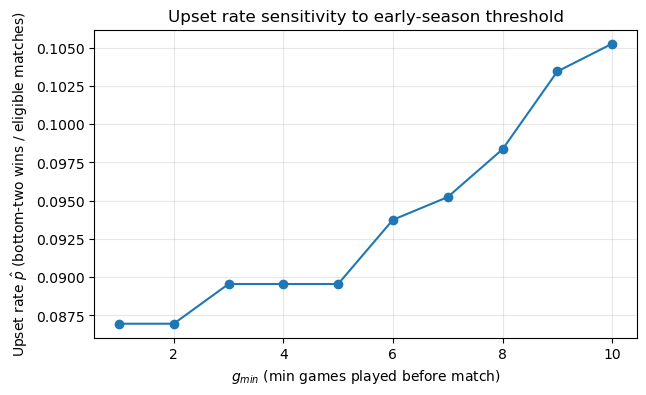

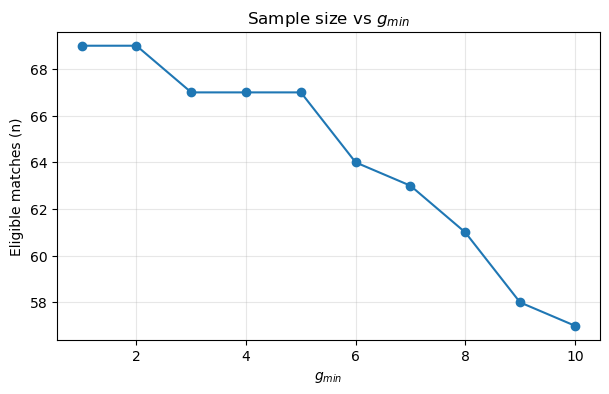

In [11]:
plt.figure(figsize=(7,4))
plt.plot(sens_df["gmin"], sens_df["upset_rate_p_hat"], marker="o")
plt.xlabel(r"$g_{min}$ (min games played before match)")
plt.ylabel(r"Upset rate $\hat{p}$ (bottom-two wins / eligible matches)")
plt.title("Upset rate sensitivity to early-season threshold")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(sens_df["gmin"], sens_df["n"], marker="o")
plt.xlabel(r"$g_{min}$")
plt.ylabel("Eligible matches (n)")
plt.title("Sample size vs $g_{min}$")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation (edit if needed):**
- If ranks are very noisy early in the season, $\hat{p}$ may fluctuate for small $g_{min}$.
- For moderate $g_{min}$ (e.g., 4–7), the estimate often stabilizes while still retaining enough matches.


### (e) Empirical goal-scoring matrix by pre-match ranks

We estimate the average goals scored by a team of pre-match rank $i$ against rank $j$.

Implementation detail:
- Create `G_tot` and `G_n` arrays of shape 20×20.
- For each match, add a **directed contribution** for the home team (rank i vs rank j) and for the away team (rank i vs rank j).
- Compute `G_mean = G_tot / G_n` element-wise.

We use the same $g_{min}=5$ filter so that ranks reflect a non-trivial history.


In [12]:
def build_goal_matrix(match_analysis: pd.DataFrame, gmin: int = 5) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    df = match_analysis.copy()
    df = df[(df["home_pre_GP"] >= gmin) & (df["away_pre_GP"] >= gmin)].copy()

    # Keep only rows with valid ranks 1..20
    df = df[df["home_pre_rank"].between(1, 20) & df["away_pre_rank"].between(1, 20)].copy()

    G_tot = np.zeros((20,20), dtype=float)
    G_n = np.zeros((20,20), dtype=float)

    for _, r in df.iterrows():
        i = int(r["home_pre_rank"])
        j = int(r["away_pre_rank"])
        hg = float(r["home_goals"])
        ag = float(r["away_goals"])

        # home contribution: i scores hg on j
        G_tot[i-1, j-1] += hg
        G_n[i-1, j-1] += 1

        # away contribution: j? careful: away rank is r["away_pre_rank"] = j, opponent rank = i
        G_tot[j-1, i-1] += ag
        G_n[j-1, i-1] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        G_mean = np.where(G_n > 0, G_tot / G_n, np.nan)

    return G_tot, G_n, G_mean

G_tot, G_n, G_mean = build_goal_matrix(match_analysis_all, gmin=5)

np.nanmean(G_mean), np.nanmin(G_mean), np.nanmax(G_mean)


(np.float64(1.4038374757738914),
 np.float64(0.5),
 np.float64(3.3333333333333335))

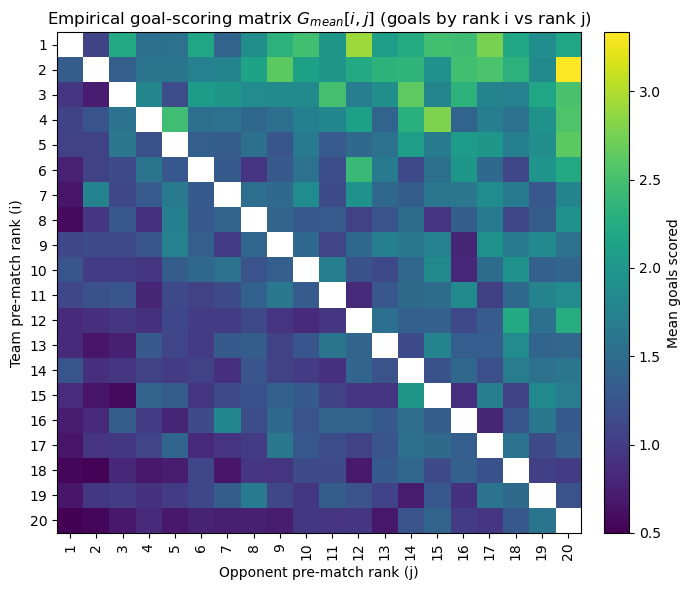

In [13]:
plt.figure(figsize=(7,6))
im = plt.imshow(G_mean, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Mean goals scored")
plt.xlabel("Opponent pre-match rank (j)")
plt.ylabel("Team pre-match rank (i)")
plt.title("Empirical goal-scoring matrix $G_{mean}[i,j]$ (goals by rank i vs rank j)")
plt.xticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1), rotation=90)
plt.yticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1))
plt.tight_layout()
plt.show()


**What to look for (edit if needed):**
- Higher-ranked teams (small i) should score more against lower-ranked opponents (large j).
- You may also see a home/away asymmetry *in the data*, but here we pooled both directions into one matrix.
- Cells with very few observations can be noisy; `G_n` can be inspected to understand sample sizes.


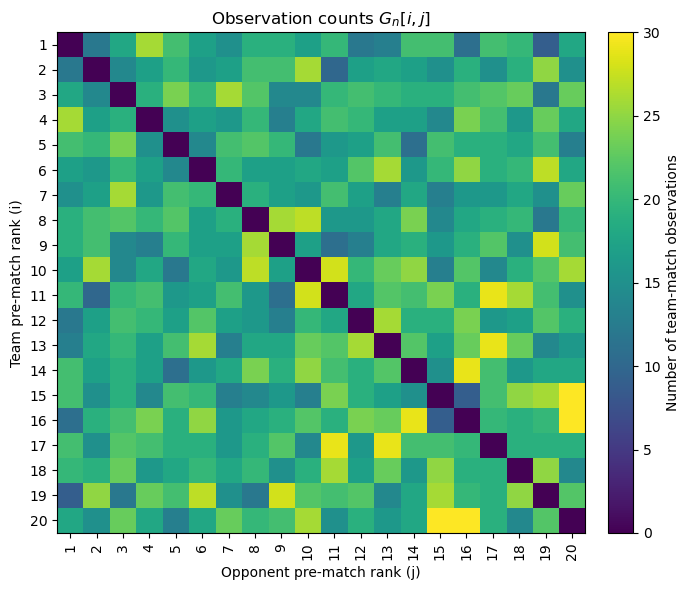

In [14]:
# Optional: visualize the number of observations per cell
plt.figure(figsize=(7,6))
im = plt.imshow(G_n, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Number of team-match observations")
plt.xlabel("Opponent pre-match rank (j)")
plt.ylabel("Team pre-match rank (i)")
plt.title("Observation counts $G_n[i,j]$")
plt.xticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1), rotation=90)
plt.yticks(ticks=np.arange(0,20,1), labels=np.arange(1,21,1))
plt.tight_layout()
plt.show()


### (f) A simple generative model for outcomes from ranks (in words, plus optional code)

A minimal probabilistic model suggested by part (e) is a **Poisson goals model** parameterized by pre-match ranks.

1. **Inputs:** the two teams' pre-match ranks $(i,j)$.
2. **Goal model:**
   - Sample home-team goals $G_H \sim \text{Poisson}(\lambda_{i,j})$ where $\lambda_{i,j} = G_{mean}[i,j]$.
   - Sample away-team goals $G_A \sim \text{Poisson}(\lambda_{j,i})$ where $\lambda_{j,i} = G_{mean}[j,i]$.
   - (Optional improvement) multiply the home mean by a scalar home-advantage factor $\alpha>1$.
3. **Outcome:** home win if $G_H>G_A$, draw if equal, away win if $G_H<G_A$.

#### Simulating a season
To simulate a 20-team season (380 games):
- Initialize all teams at rank 1..20 (or all tied at start),
- Iterate through a full double round-robin schedule,
- Before each match, use current standings to obtain ranks $(i,j)$,
- Sample goals using the Poisson model above,
- Update standings using EPL points and tiebreakers.

#### Evaluating the model
After simulating many seasons, compare simulated vs empirical summaries such as:
- Overall home/draw/away rates,
- Distribution of total goals per match,
- Points distribution across teams,
- Empirical upset rate (as in part (c)) and its sensitivity curve (part (d)),
- Rank correlation between simulated final tables and empirical final tables (if you map team identities).

Below is an **optional** reference implementation to simulate seasons using rank-dependent Poisson scoring.


In [15]:
# -----------------------------
# OPTIONAL: simple simulator
# -----------------------------
from itertools import combinations

def round_robin_schedule(teams: list[str]) -> list[tuple[str,str]]:
    """One double round-robin schedule: each pair plays twice (home/away)."""
    fixtures = []
    for a, b in combinations(teams, 2):
        fixtures.append((a, b))  # a home
        fixtures.append((b, a))  # b home
    return fixtures

def simulate_season_from_Gmean(G_mean: np.ndarray, seed: int = 0, alpha_home: float = 1.0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    teams = [f"Team{i}" for i in range(1, 21)]
    fixtures = round_robin_schedule(teams)

    # start with all zero stats; ranks alphabetical at start
    date0 = pd.Timestamp("2000-08-01")
    table = init_standings(teams, date0)

    def get_rank(team: str) -> int:
        return int(table.loc[table["Team"] == team, "Rank"].iloc[0])

    for home, away in fixtures:
        i = get_rank(home)
        j = get_rank(away)

        lam_h = G_mean[i-1, j-1]
        lam_a = G_mean[j-1, i-1]
        # if missing cells exist, fall back to global mean
        if not np.isfinite(lam_h):
            lam_h = np.nanmean(G_mean)
        if not np.isfinite(lam_a):
            lam_a = np.nanmean(G_mean)

        hg = rng.poisson(alpha_home * lam_h)
        ag = rng.poisson(lam_a)

        table = apply_match_to_table(table, home, away, int(hg), int(ag))
        # (We ignore dates inside the simulator; standings are purely sequential.)

    return table.sort_values("Rank").reset_index(drop=True)

# quick demo:
sim_table = simulate_season_from_Gmean(G_mean, seed=42, alpha_home=1.05)
sim_table[["Rank","Team","Pts","GD","GF","GA","W","D","L"]].head(10)


,Rank,Team,Pts,GD,GF,GA,W,D,L
0,1,Team3,91,63,94,31,29,4,5
1,2,Team1,73,41,79,38,21,10,7
2,3,Team19,71,11,72,61,21,8,9
3,4,Team7,68,31,80,49,20,8,10
4,5,Team5,63,7,47,40,18,9,11
5,6,Team14,61,18,58,40,16,13,9
6,7,Team4,59,13,69,56,17,8,13
7,8,Team9,59,-4,47,51,19,2,17
8,9,Team10,58,15,63,48,16,10,12
9,10,Team17,54,-8,46,54,16,6,16


**Interpretation (edit if needed):**
- This simulator uses *current* ranks to set goal-rate parameters, so early randomness can cascade into later ranks.
- If the simulated distributions resemble the empirical ones (home win rate, goals per match, upset rate), the model is a reasonable first approximation.
- If not, common extensions include adding team fixed effects (attack/defense strength), explicit home advantage, or time-varying strength.
